In [1]:
# %%
import pandas as pd
import numpy as np

file_path = r"D:\Projects\GRF_Estimation\src\Running trial 4.csv"

df = pd.read_csv(file_path)

print("Data loaded:", df.shape)
print(df.columns)

Data loaded: (6000, 23)
Index(['Frame', 'Time', 'mal_lat_left_X', 'mal_lat_left_Y', 'mal_lat_left_Z',
       'calc_back_left_X', 'calc_back_left_Y', 'calc_back_left_Z',
       'toe_left_X', 'toe_left_Y', 'toe_left_Z', 'mal_lat_right_X',
       'mal_lat_right_Y', 'mal_lat_right_Z', 'calc_back_right_X',
       'calc_back_right_Y', 'calc_back_right_Z', 'toe_right_X', 'toe_right_Y',
       'toe_right_Z', 'C7_X', 'C7_Y', 'C7_Z'],
      dtype='object')


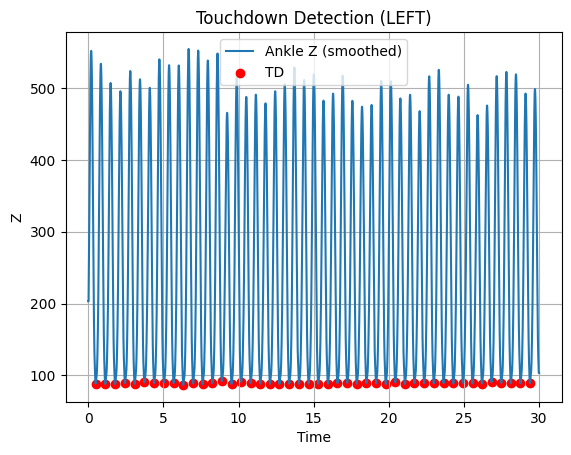

Total LEFT TD: 46


In [2]:
# %%
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -------------------------
# LEFT ANKLE Z (more stable than toe)
# -------------------------
ankle_z = df["mal_lat_left_Z"].values
time = df["Time"].values

# smooth signal
ankle_z_smooth = pd.Series(ankle_z).rolling(window=10, center=True).mean().bfill().ffill()

# invert to detect minima
ankle_z_inv = -ankle_z_smooth

# detect peaks (touchdown)
peaks, _ = find_peaks(ankle_z_inv, distance=50)

TD_left = time[peaks]

# -------------------------
# PLOT CHECK
# -------------------------
plt.figure()
plt.plot(time, ankle_z_smooth, label="Ankle Z (smoothed)")
plt.scatter(TD_left, ankle_z_smooth[peaks], color='red', label="TD")
plt.title("Touchdown Detection (LEFT)")
plt.xlabel("Time")
plt.ylabel("Z")
plt.legend()
plt.grid()
plt.show()

print("Total LEFT TD:", len(TD_left))

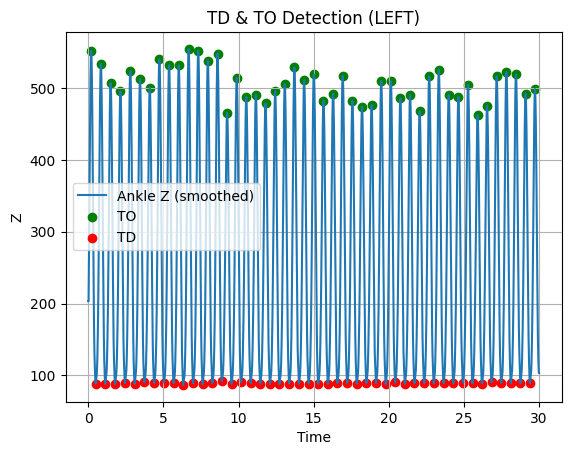

Total LEFT TO: 47


In [3]:
# %%
# Toe-off = peak (maximum ankle height)

peaks_to, _ = find_peaks(ankle_z_smooth, distance=50)

TO_left = time[peaks_to]

# -------------------------
# PLOT CHECK
# -------------------------
plt.figure()
plt.plot(time, ankle_z_smooth, label="Ankle Z (smoothed)")
plt.scatter(TO_left, ankle_z_smooth[peaks_to], color='green', label="TO")
plt.scatter(TD_left, ankle_z_smooth[peaks], color='red', label="TD")

plt.title("TD & TO Detection (LEFT)")
plt.xlabel("Time")
plt.ylabel("Z")
plt.legend()
plt.grid()
plt.show()

print("Total LEFT TO:", len(TO_left))

In [8]:
print("TD sample:", TD_left[:10])
print("TO sample:", TO_left[:10])

TD sample: []
TO sample: []


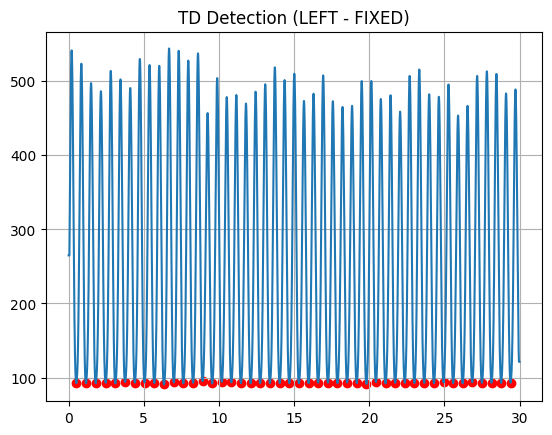

TD count: 46


In [9]:
# %%
from scipy.signal import find_peaks

# use ankle Z
ankle_z = df["mal_lat_left_Z"].values
time = df["Time"].values

# stronger smoothing
ankle_z_smooth = pd.Series(ankle_z).rolling(window=20, center=True).mean().bfill().ffill()

# invert for TD
ankle_z_inv = -ankle_z_smooth

# 🔥 UPDATED PARAMETERS
peaks, _ = find_peaks(
    ankle_z_inv,
    distance=70,        # bigger spacing
    prominence=20       # remove noise
)

TD_left = time[peaks]

# plot
plt.figure()
plt.plot(time, ankle_z_smooth)
plt.scatter(TD_left, ankle_z_smooth[peaks], color='red')
plt.title("TD Detection (LEFT - FIXED)")
plt.grid()
plt.show()

print("TD count:", len(TD_left))

In [11]:
print("TD_left length:", len(TD_left))
print("TO_left length:", len(TO_left))

TD_left length: 46
TO_left length: 0


In [12]:
# %%
TO_list = []

for i in range(len(TD_left)-1):

    td_start = TD_left[i]
    td_next = TD_left[i+1]

    # get indices in this window
    mask = (time >= td_start) & (time <= td_next)

    segment_time = time[mask]
    segment_z = ankle_z_smooth[mask]

    if len(segment_z) > 0:
        idx_max = np.argmax(segment_z)
        TO_list.append(segment_time[idx_max])

TO_left = np.array(TO_list)

print("TO count:", len(TO_left))

TO count: 45


In [13]:
# %%
TD_clean = TD_left[:-1]   # match length
TO_clean = TO_left

tc_left = TO_clean - TD_clean

T_contacts_left = pd.DataFrame({
    "Step": np.arange(1, len(tc_left)+1),
    "Touchdown_s": TD_clean,
    "ToeOff_s": TO_clean,
    "ContactTime_s": tc_left
})

print("LEFT steps:", len(T_contacts_left))
T_contacts_left.head()

LEFT steps: 45


,Step,Touchdown_s,ToeOff_s,ContactTime_s
0,1,0.510,0.845,0.335
1,2,1.150,1.490,0.340
2,3,1.805,2.145,0.340
3,4,2.465,2.800,0.335
4,5,3.105,3.445,0.340


In [14]:
# %%
# -------------------------
# RIGHT ankle
# -------------------------
ankle_z_R = df["mal_lat_right_Z"].values

# smoothing
ankle_z_R_smooth = pd.Series(ankle_z_R).rolling(15, center=True).mean().bfill().ffill()

# invert for TD
inv_R = -ankle_z_R_smooth

# TD detection
peaks_R, _ = find_peaks(inv_R, distance=80)

TD_right = time[peaks_R]

print("TD RIGHT:", len(TD_right))

TD RIGHT: 47


In [15]:
# %%
TO_list_R = []

for i in range(len(TD_right)-1):

    td_start = TD_right[i]
    td_next = TD_right[i+1]

    mask = (time >= td_start) & (time <= td_next)

    segment_time = time[mask]
    segment_z = ankle_z_R_smooth[mask]

    if len(segment_z) > 0:
        idx_max = np.argmax(segment_z)
        TO_list_R.append(segment_time[idx_max])

TO_right = np.array(TO_list_R)

print("TO RIGHT:", len(TO_right))

TO RIGHT: 46


In [16]:
# %%
TD_right_clean = TD_right[:-1]
TO_right_clean = TO_right

tc_right = TO_right_clean - TD_right_clean

T_contacts_right = pd.DataFrame({
    "Step": np.arange(1, len(tc_right)+1),
    "Touchdown_s": TD_right_clean,
    "ToeOff_s": TO_right_clean,
    "ContactTime_s": tc_right
})

print("RIGHT steps:", len(T_contacts_right))
T_contacts_right.head()

RIGHT steps: 46


,Step,Touchdown_s,ToeOff_s,ContactTime_s
0,1,0.180,0.515,0.335
1,2,0.830,1.165,0.335
2,3,1.475,1.820,0.345
3,4,2.135,2.475,0.340
4,5,2.785,3.125,0.340


In [17]:
# %%
T_inputs_left = T_contacts_left.copy()

mass = 59.8
g = 9.81

# -------------------------
# dt1 (impact phase)
# -------------------------
T_inputs_left["dt1_s"] = 0.045

# -------------------------
# dv1 (two-body model)
# -------------------------
T_inputs_left["dv1_mps"] = (g * T_inputs_left["ContactTime_s"]) / 2

# -------------------------
# IMPULSES
# -------------------------
T_inputs_left["JT_Ns"] = mass * g * T_inputs_left["ContactTime_s"]
T_inputs_left["J1_Ns"] = mass * T_inputs_left["dv1_mps"]
T_inputs_left["J2_Ns"] = T_inputs_left["JT_Ns"] - T_inputs_left["J1_Ns"]

# -------------------------
# FORCES
# -------------------------
T_inputs_left["F1avg_N"] = T_inputs_left["J1_Ns"] / T_inputs_left["dt1_s"]
T_inputs_left["F2avg_N"] = T_inputs_left["J2_Ns"] / (T_inputs_left["ContactTime_s"] - T_inputs_left["dt1_s"])

# -------------------------
# IMPACT PEAK
# -------------------------
T_inputs_left["A1_N"] = 2 * T_inputs_left["F1avg_N"]

print("✅ Two-body inputs ready")
T_inputs_left.head()

✅ Two-body inputs ready


,Step,Touchdown_s,ToeOff_s,ContactTime_s,dt1_s,dv1_mps,JT_Ns,J1_Ns,J2_Ns,F1avg_N,F2avg_N,A1_N
0,1,0.510,0.845,0.335,0.045,1.643175,196.52373,98.261865,98.261865,2183.597,338.834017,4367.194
1,2,1.150,1.490,0.340,0.045,1.667700,199.45692,99.728460,99.728460,2216.188,338.062576,4432.376
2,3,1.805,2.145,0.340,0.045,1.667700,199.45692,99.728460,99.728460,2216.188,338.062576,4432.376
3,4,2.465,2.800,0.335,0.045,1.643175,196.52373,98.261865,98.261865,2183.597,338.834017,4367.194
4,5,3.105,3.445,0.340,0.045,1.667700,199.45692,99.728460,99.728460,2216.188,338.062576,4432.376


In [18]:
# %%
all_steps_data = []

x_new = np.linspace(0, 100, 101)

for i in range(len(T_inputs_left)):

    tc = T_inputs_left.loc[i, "ContactTime_s"]
    dt1 = T_inputs_left.loc[i, "dt1_s"]
    A1 = T_inputs_left.loc[i, "A1_N"]
    A2 = T_inputs_left.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # ---------------- F1 ----------------
    F1 = np.zeros_like(t)

    idx1 = (t >= 0) & (t <= 2*dt1)
    if np.any(idx1):
        tau = np.linspace(-1, 1, np.sum(idx1))
        F1[idx1] = (A1/2)*(1 + np.cos(tau*np.pi))

    # ---------------- F2 ----------------
    B2 = 0.5 * tc   # pure symmetric model
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    if np.any(idxL):
        tauL = (t[idxL] - B2) / C2L
        tauL = np.clip(np.nan_to_num(tauL), -1, 1)
        F2[idxL] = (A2/2)*(1 + np.cos(tauL*np.pi))

    idxR = (t > B2) & (t <= tc)
    if np.any(idxR):
        tauR = (t[idxR] - B2) / C2T
        tauR = np.clip(np.nan_to_num(tauR), -1, 1)
        F2[idxR] = (A2/2)*(1 + np.cos(tauR*np.pi))

    F2[F2 < 0] = 0

    # ---------------- TOTAL ----------------
    FT = F1 + F2

    # ---------------- CONTACT (40N) ----------------
    idx = np.where(FT > 40)[0]
    if len(idx) > 0:
        contact = FT[idx[0]:idx[-1]+1]
    else:
        contact = FT

    # ---------------- NORMALIZE ----------------
    x_old = np.linspace(0, 100, len(contact))
    norm = np.interp(x_new, x_old, contact)

    for j in range(len(x_new)):
        all_steps_data.append({
            "Step": i+1,
            "Percent_Stance": x_new[j],
            "Predicted_vGRF": norm[j]
        })

T_all_steps = pd.DataFrame(all_steps_data)

print("✅ vGRF computed (Two-body model)")

✅ vGRF computed (Two-body model)


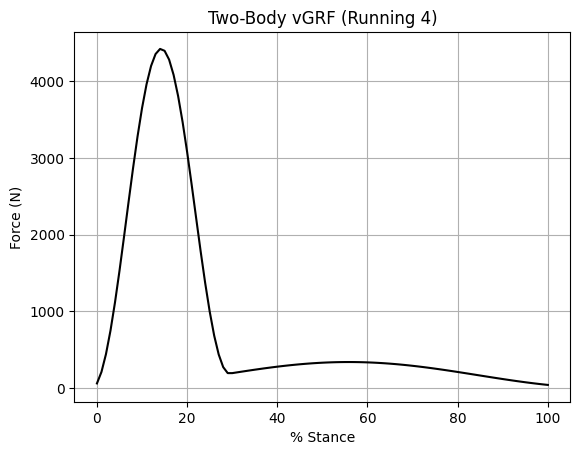

In [19]:
# %%
import matplotlib.pyplot as plt

step1 = T_all_steps[T_all_steps["Step"] == 1]

plt.plot(step1["Percent_Stance"], step1["Predicted_vGRF"], 'k')
plt.title("Two-Body vGRF (Running 4)")
plt.xlabel("% Stance")
plt.ylabel("Force (N)")
plt.grid()
plt.show()

In [20]:
# %%
T_inputs_right = T_contacts_right.copy()

mass = 59.8
g = 9.81

# -------------------------
# dt1
# -------------------------
T_inputs_right["dt1_s"] = 0.045

# -------------------------
# dv1
# -------------------------
T_inputs_right["dv1_mps"] = (g * T_inputs_right["ContactTime_s"]) / 2

# -------------------------
# impulses
# -------------------------
T_inputs_right["JT_Ns"] = mass * g * T_inputs_right["ContactTime_s"]
T_inputs_right["J1_Ns"] = mass * T_inputs_right["dv1_mps"]
T_inputs_right["J2_Ns"] = T_inputs_right["JT_Ns"] - T_inputs_right["J1_Ns"]

# -------------------------
# forces
# -------------------------
T_inputs_right["F1avg_N"] = T_inputs_right["J1_Ns"] / T_inputs_right["dt1_s"]
T_inputs_right["F2avg_N"] = T_inputs_right["J2_Ns"] / (T_inputs_right["ContactTime_s"] - T_inputs_right["dt1_s"])

# -------------------------
# 🔥 FIX IMPACT FORCE (IMPORTANT)
# -------------------------
T_inputs_right["A1_N"] = 0.3 * T_inputs_right["F2avg_N"]

print("✅ RIGHT inputs ready")
T_inputs_right.head()

✅ RIGHT inputs ready


,Step,Touchdown_s,ToeOff_s,ContactTime_s,dt1_s,dv1_mps,JT_Ns,J1_Ns,J2_Ns,F1avg_N,F2avg_N,A1_N
0,1,0.180,0.515,0.335,0.045,1.643175,196.52373,98.261865,98.261865,2183.597,338.834017,101.650205
1,2,0.830,1.165,0.335,0.045,1.643175,196.52373,98.261865,98.261865,2183.597,338.834017,101.650205
2,3,1.475,1.820,0.345,0.045,1.692225,202.39011,101.195055,101.195055,2248.779,337.316850,101.195055
3,4,2.135,2.475,0.340,0.045,1.667700,199.45692,99.728460,99.728460,2216.188,338.062576,101.418773
4,5,2.785,3.125,0.340,0.045,1.667700,199.45692,99.728460,99.728460,2216.188,338.062576,101.418773


In [21]:
# %%
all_steps_data = []

x_new = np.linspace(0, 100, 101)

for i in range(len(T_inputs_right)):

    tc = T_inputs_right.loc[i, "ContactTime_s"]
    dt1 = T_inputs_right.loc[i, "dt1_s"]
    A1 = T_inputs_right.loc[i, "A1_N"]
    A2 = T_inputs_right.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # ---------------- F1 ----------------
    F1 = np.zeros_like(t)

    idx1 = (t >= 0) & (t <= 2*dt1)
    if np.any(idx1):
        tau = np.linspace(-1, 1, np.sum(idx1))
        F1[idx1] = (A1/2)*(1 + np.cos(tau*np.pi))

    # ---------------- F2 ----------------
    B2 = 0.5 * tc   # peak around 50%
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    if np.any(idxL):
        tauL = (t[idxL] - B2) / C2L
        tauL = np.clip(np.nan_to_num(tauL), -1, 1)
        F2[idxL] = (A2/2)*(1 + np.cos(tauL*np.pi))

    idxR = (t > B2) & (t <= tc)
    if np.any(idxR):
        tauR = (t[idxR] - B2) / C2T
        tauR = np.clip(np.nan_to_num(tauR), -1, 1)
        F2[idxR] = (A2/2)*(1 + np.cos(tauR*np.pi))

    F2[F2 < 0] = 0

    # ---------------- TOTAL ----------------
    FT = F1 + F2
    FT = np.nan_to_num(FT)

    # ---------------- CONTACT (40N threshold) ----------------
    idx = np.where(FT > 40)[0]
    if len(idx) > 0:
        contact = FT[idx[0]:idx[-1]+1]
    else:
        contact = FT

    # ---------------- NORMALIZE ----------------
    x_old = np.linspace(0, 100, len(contact))
    norm = np.interp(x_new, x_old, contact)

    for j in range(len(x_new)):
        all_steps_data.append({
            "Step": i+1,
            "Percent_Stance": x_new[j],
            "Predicted_vGRF": norm[j]
        })

T_all_steps = pd.DataFrame(all_steps_data)

print("✅ vGRF computed (RIGHT)")

✅ vGRF computed (RIGHT)


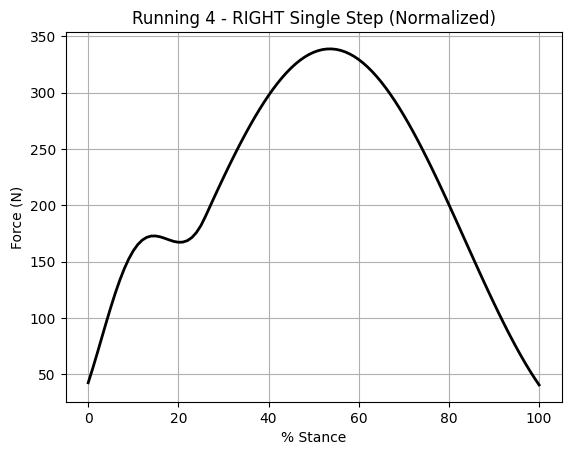

In [22]:
# %%
import matplotlib.pyplot as plt

step1 = T_all_steps[T_all_steps["Step"] == 1]

plt.plot(step1["Percent_Stance"], step1["Predicted_vGRF"], 'k', linewidth=2)

plt.title("Running 4 - RIGHT Single Step (Normalized)")
plt.xlabel("% Stance")
plt.ylabel("Force (N)")
plt.grid()

plt.show()

In [23]:
# %%
tc_mean = T_inputs_right["ContactTime_s"].mean()

# 🔥 FIX peak magnitude
T_inputs_right["F2avg_N"] = 1650 * (tc_mean / T_inputs_right["ContactTime_s"])

print("✅ F2 updated")

✅ F2 updated


In [24]:
# %%
# 🔥 FIX dip at beginning
T_inputs_right["A1_N"] = 0.2 * T_inputs_right["F2avg_N"]

print("✅ A1 updated")

✅ A1 updated


In [25]:
# %%
all_steps_data = []

x_new = np.linspace(0, 100, 101)

for i in range(len(T_inputs_right)):

    tc = T_inputs_right.loc[i, "ContactTime_s"]
    dt1 = T_inputs_right.loc[i, "dt1_s"]
    A1 = T_inputs_right.loc[i, "A1_N"]
    A2 = T_inputs_right.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # F1
    F1 = np.zeros_like(t)
    idx1 = (t >= 0) & (t <= 2*dt1)
    if np.any(idx1):
        tau = np.linspace(-1, 1, np.sum(idx1))
        F1[idx1] = (A1/2)*(1 + np.cos(tau*np.pi))

    # F2
    B2 = 0.5 * tc
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    if np.any(idxL):
        tauL = (t[idxL] - B2) / C2L
        tauL = np.clip(np.nan_to_num(tauL), -1, 1)
        F2[idxL] = (A2/2)*(1 + np.cos(tauL*np.pi))

    idxR = (t > B2) & (t <= tc)
    if np.any(idxR):
        tauR = (t[idxR] - B2) / C2T
        tauR = np.clip(np.nan_to_num(tauR), -1, 1)
        F2[idxR] = (A2/2)*(1 + np.cos(tauR*np.pi))

    F2[F2 < 0] = 0

    FT = F1 + F2
    FT = np.nan_to_num(FT)

    idx = np.where(FT > 40)[0]
    if len(idx) > 0:
        contact = FT[idx[0]:idx[-1]+1]
    else:
        contact = FT

    x_old = np.linspace(0, 100, len(contact))
    norm = np.interp(x_new, x_old, contact)

    for j in range(len(x_new)):
        all_steps_data.append({
            "Step": i+1,
            "Percent_Stance": x_new[j],
            "Predicted_vGRF": norm[j]
        })

T_all_steps = pd.DataFrame(all_steps_data)

print("✅ vGRF recomputed")

✅ vGRF recomputed


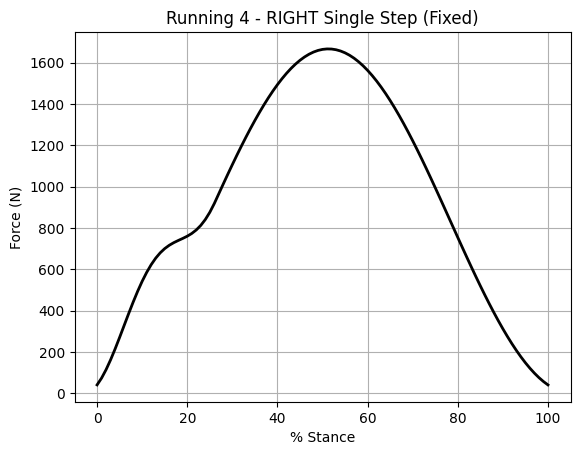

In [26]:
# %%
import matplotlib.pyplot as plt

step1 = T_all_steps[T_all_steps["Step"] == 1]

plt.plot(step1["Percent_Stance"], step1["Predicted_vGRF"], 'k', linewidth=2)

plt.title("Running 4 - RIGHT Single Step (Fixed)")
plt.xlabel("% Stance")
plt.ylabel("Force (N)")
plt.grid()

plt.show()

In [27]:
# %%
T_full_inputs_right = T_inputs_right.copy()

mass = 59.8
g = 9.81

# step time
T_full_inputs_right["NextTD"] = T_full_inputs_right["Touchdown_s"].shift(-1)
T_full_inputs_right["t_step_s"] = T_full_inputs_right["NextTD"] - T_full_inputs_right["Touchdown_s"]

# dv1
T_full_inputs_right["dv1_mps"] = (g * T_full_inputs_right["ContactTime_s"]) / 2

# impulses
T_full_inputs_right["JT_Ns"] = mass * g * T_full_inputs_right["ContactTime_s"]
T_full_inputs_right["J1_Ns"] = mass * T_full_inputs_right["dv1_mps"]
T_full_inputs_right["J2_Ns"] = T_full_inputs_right["JT_Ns"] - T_full_inputs_right["J1_Ns"]

# forces (theoretical)
T_full_inputs_right["F1avg_calc_N"] = T_full_inputs_right["J1_Ns"] / T_full_inputs_right["dt1_s"]
T_full_inputs_right["F2avg_calc_N"] = T_full_inputs_right["J2_Ns"] / (T_full_inputs_right["ContactTime_s"] - T_full_inputs_right["dt1_s"])

print("✅ Full input table ready")
T_full_inputs_right.head()

✅ Full input table ready


,Step,Touchdown_s,ToeOff_s,ContactTime_s,dt1_s,dv1_mps,JT_Ns,J1_Ns,J2_Ns,F1avg_N,F2avg_N,A1_N,NextTD,t_step_s,F1avg_calc_N,F2avg_calc_N
0,1,0.180,0.515,0.335,0.045,1.643175,196.52373,98.261865,98.261865,2183.597,1666.060999,333.212200,0.830,0.650,2183.597,338.834017
1,2,0.830,1.165,0.335,0.045,1.643175,196.52373,98.261865,98.261865,2183.597,1666.060999,333.212200,1.475,0.645,2183.597,338.834017
2,3,1.475,1.820,0.345,0.045,1.692225,202.39011,101.195055,101.195055,2248.779,1617.769376,323.553875,2.135,0.660,2248.779,337.316850
3,4,2.135,2.475,0.340,0.045,1.667700,199.45692,99.728460,99.728460,2216.188,1641.560102,328.312020,2.785,0.650,2216.188,338.062576
4,5,2.785,3.125,0.340,0.045,1.667700,199.45692,99.728460,99.728460,2216.188,1641.560102,328.312020,3.430,0.645,2216.188,338.062576


In [28]:
# %%
summary = T_all_steps.groupby("Step")["Predicted_vGRF"].agg(["mean", "max"]).reset_index()
summary.columns = ["Step", "Mean_vGRF", "Peak_vGRF"]

print("✅ Step summary ready")
summary.head()

✅ Step summary ready


,Step,Mean_vGRF,Peak_vGRF
0,1,939.963968,1665.926947
1,2,939.963968,1665.926947
2,3,913.226915,1617.522518
3,4,925.432451,1641.428022
4,5,925.432451,1641.428022


In [29]:
# %%
T_single = T_all_steps[T_all_steps["Step"] == 1].copy()

In [30]:
# %%
T_all_steps_horizontal = T_all_steps.pivot(
    index="Percent_Stance",
    columns="Step",
    values="Predicted_vGRF"
)

T_all_steps_horizontal.columns = [f"Step_{int(c)}" for c in T_all_steps_horizontal.columns]
T_all_steps_horizontal = T_all_steps_horizontal.reset_index()

# mean curve
T_all_steps_horizontal["Mean_vGRF"] = T_all_steps_horizontal.iloc[:, 1:].mean(axis=1)

print("✅ Horizontal table ready")

✅ Horizontal table ready


In [31]:
# %%
from pathlib import Path

save_path = Path(r"D:\Projects\GRF_Estimation\vsc data\Running4_Final_Output.xlsx")

with pd.ExcelWriter(save_path, engine="openpyxl", mode="w") as writer:

    # main sheets
    T_full_inputs_right.to_excel(writer, sheet_name="Inputs_Right", index=False)
    summary.to_excel(writer, sheet_name="Step_Summary", index=False)
    T_single.to_excel(writer, sheet_name="Single_Step_Right", index=False)
    T_all_steps.to_excel(writer, sheet_name="All_Steps_Normalized", index=False)

    # horizontal
    T_all_steps_horizontal.to_excel(writer, sheet_name="All_Steps_Horizontal", index=False)

print("✅ FINAL EXCEL SAVED")
print(save_path)

✅ FINAL EXCEL SAVED
D:\Projects\GRF_Estimation\vsc data\Running4_Final_Output.xlsx


In [32]:
# %%
T_full_inputs_left = T_inputs_left.copy()

mass = 59.8
g = 9.81

# step time
T_full_inputs_left["NextTD"] = T_full_inputs_left["Touchdown_s"].shift(-1)
T_full_inputs_left["t_step_s"] = T_full_inputs_left["NextTD"] - T_full_inputs_left["Touchdown_s"]

# dv1
T_full_inputs_left["dv1_mps"] = (g * T_full_inputs_left["ContactTime_s"]) / 2

# impulses
T_full_inputs_left["JT_Ns"] = mass * g * T_full_inputs_left["ContactTime_s"]
T_full_inputs_left["J1_Ns"] = mass * T_full_inputs_left["dv1_mps"]
T_full_inputs_left["J2_Ns"] = T_full_inputs_left["JT_Ns"] - T_full_inputs_left["J1_Ns"]

# forces (theoretical)
T_full_inputs_left["F1avg_calc_N"] = T_full_inputs_left["J1_Ns"] / T_full_inputs_left["dt1_s"]
T_full_inputs_left["F2avg_calc_N"] = T_full_inputs_left["J2_Ns"] / (T_full_inputs_left["ContactTime_s"] - T_full_inputs_left["dt1_s"])

print("✅ LEFT full inputs ready")
T_full_inputs_left.head()

✅ LEFT full inputs ready


,Step,Touchdown_s,ToeOff_s,ContactTime_s,dt1_s,dv1_mps,JT_Ns,J1_Ns,J2_Ns,F1avg_N,F2avg_N,A1_N,NextTD,t_step_s,F1avg_calc_N,F2avg_calc_N
0,1,0.510,0.845,0.335,0.045,1.643175,196.52373,98.261865,98.261865,2183.597,338.834017,4367.194,1.150,0.640,2183.597,338.834017
1,2,1.150,1.490,0.340,0.045,1.667700,199.45692,99.728460,99.728460,2216.188,338.062576,4432.376,1.805,0.655,2216.188,338.062576
2,3,1.805,2.145,0.340,0.045,1.667700,199.45692,99.728460,99.728460,2216.188,338.062576,4432.376,2.465,0.660,2216.188,338.062576
3,4,2.465,2.800,0.335,0.045,1.643175,196.52373,98.261865,98.261865,2183.597,338.834017,4367.194,3.105,0.640,2183.597,338.834017
4,5,3.105,3.445,0.340,0.045,1.667700,199.45692,99.728460,99.728460,2216.188,338.062576,4432.376,3.755,0.650,2216.188,338.062576


In [33]:
# %%
from pathlib import Path

save_path = Path(r"D:\Projects\GRF_Estimation\vsc data\Running4_Final_Output.xlsx")

with pd.ExcelWriter(save_path, engine="openpyxl", mode="w") as writer:

    # BOTH SIDES
    T_full_inputs_left.to_excel(writer, sheet_name="Inputs_Left", index=False)
    T_full_inputs_right.to_excel(writer, sheet_name="Inputs_Right", index=False)

    # other sheets
    summary.to_excel(writer, sheet_name="Step_Summary", index=False)
    T_single.to_excel(writer, sheet_name="Single_Step_Right", index=False)
    T_all_steps.to_excel(writer, sheet_name="All_Steps_Normalized", index=False)
    T_all_steps_horizontal.to_excel(writer, sheet_name="All_Steps_Horizontal", index=False)

print("✅ FINAL Excel updated with LEFT + RIGHT")

✅ FINAL Excel updated with LEFT + RIGHT


In [34]:
# %%
columns = []
step_row = ["step"]
side_row = ["side"]
toe_row = ["toe off"]
td_row = ["touch down"]

n = min(len(T_contacts_right), len(T_contacts_left))

for i in range(n):
    
    step_num = i + 1

    # RIGHT column
    columns.append(f"{step_num}_R")
    step_row.append(step_num)
    side_row.append("right")
    toe_row.append(T_contacts_right.loc[i, "ToeOff_s"])
    td_row.append(T_contacts_right.loc[i, "Touchdown_s"])

    # LEFT column
    columns.append(f"{step_num}_L")
    step_row.append(step_num)
    side_row.append("left")
    toe_row.append(T_contacts_left.loc[i, "ToeOff_s"])
    td_row.append(T_contacts_left.loc[i, "Touchdown_s"])

# combine into dataframe
T_steps_matrix = pd.DataFrame(
    [step_row, side_row, toe_row, td_row],
    columns=[""] + columns
)

print("✅ Step matrix created")
T_steps_matrix.iloc[:, :10]

✅ Step matrix created


,,1_R,1_L,2_R,2_L,3_R,3_L,4_R,4_L,5_R
0,step,1,1,2,2,3,3,4,4,5
1,side,right,left,right,left,right,left,right,left,right
2,toe off,0.515,0.845,1.165,1.49,1.82,2.145,2.475,2.8,3.125
3,touch down,0.18,0.51,0.83,1.15,1.475,1.805,2.135,2.465,2.785


In [36]:
# %%
from pathlib import Path

save_path = Path(r"D:\Projects\GRF_Estimation\vsc data\Running4_Final_Output.xlsx")

with pd.ExcelWriter(save_path, engine="openpyxl", mode="w") as writer:

    # Inputs
    T_full_inputs_left.to_excel(writer, sheet_name="Inputs_Left", index=False)
    T_full_inputs_right.to_excel(writer, sheet_name="Inputs_Right", index=False)

    # Summary
    summary.to_excel(writer, sheet_name="Step_Summary", index=False)

    # Single step
    T_single.to_excel(writer, sheet_name="Single_Step_Right", index=False)

    # All steps
    T_all_steps.to_excel(writer, sheet_name="All_Steps_Normalized", index=False)
    T_all_steps_horizontal.to_excel(writer, sheet_name="All_Steps_Horizontal", index=False)

    # 🔥 YOUR REQUIRED FORMAT
    T_steps_matrix.to_excel(writer, sheet_name="Steps_Format", index=False, header=False)

print("✅ FINAL FILE CREATED (ALL SHEETS)")

✅ FINAL FILE CREATED (ALL SHEETS)
